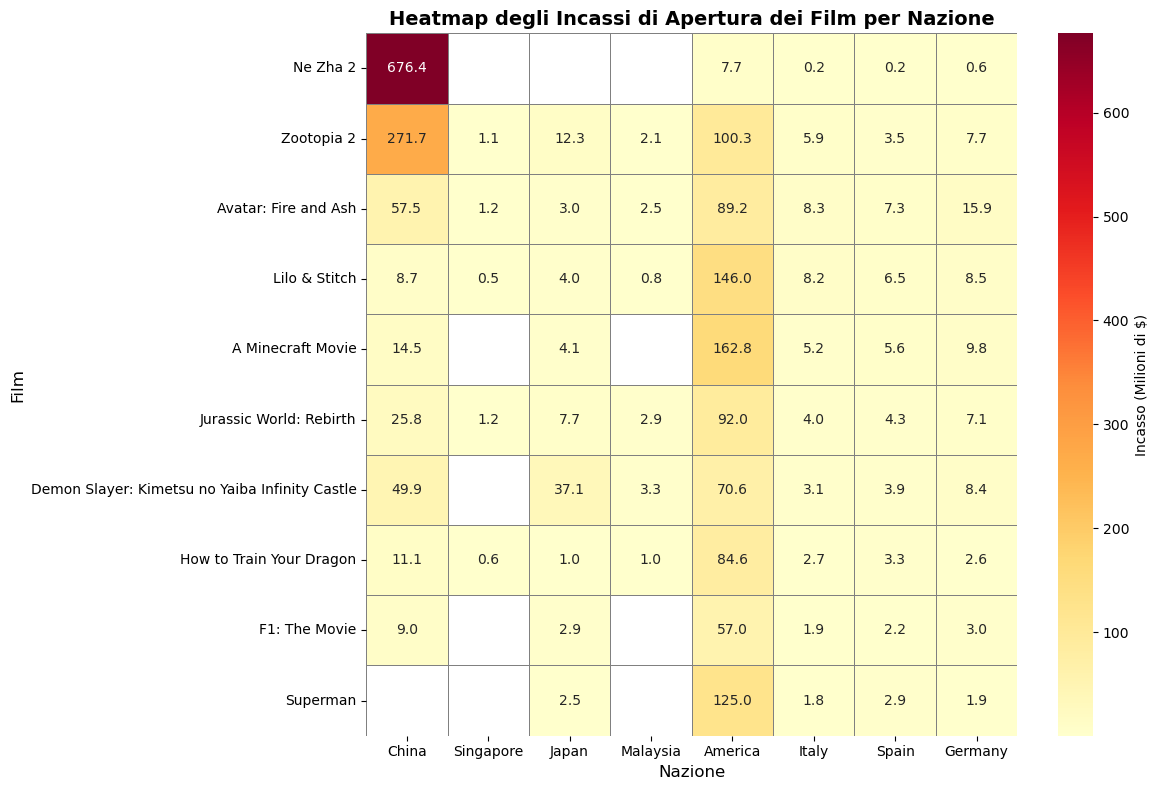

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carica i dati
df = pd.read_csv('opening - Foglio1 (1).csv')

# Prepara i dati per la heatmap
heatmap_df = df.copy()
columns_to_convert = heatmap_df.columns[1:]  # Tutte le colonne tranne "Nome film"

for col in columns_to_convert:
    # Sostituisci '-' con NaN
    heatmap_df[col] = heatmap_df[col].replace('-', np.nan)
    
    # Rimuovi il simbolo $ e le virgole, poi converti in float
    heatmap_df[col] = heatmap_df[col].str.replace('$', '', regex=False)
    heatmap_df[col] = heatmap_df[col].str.replace(',', '', regex=False)
    heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors='coerce')

# Imposta i nomi dei film come indice
heatmap_df.set_index('Nome film', inplace=True)

# Converti i valori in milioni per una lettura più facile
heatmap_millions = heatmap_df / 1000000

# Crea la figura
plt.figure(figsize=(12, 8))

# Crea la heatmap
sns.heatmap(heatmap_millions, 
            cmap='YlOrRd', 
            annot=True, 
            fmt='.1f',
            cbar_kws={'label': 'Incasso (Milioni di $)'},
            linewidths=0.5,
            linecolor='gray')

plt.title('Heatmap degli Incassi di Apertura dei Film per Nazione', fontsize=14, fontweight='bold')
plt.xlabel('Nazione', fontsize=12)
plt.ylabel('Film', fontsize=12)
plt.tight_layout()
plt.show()